In [1]:
import pandas as pd
import torch
import os
import numpy as np
from torch_geometric.data import Data
from sklearn.metrics.pairwise import cosine_similarity
from add_id import *
import matplotlib.pyplot as plt
import math
from matplotlib import cm as CM
from sklearn.manifold import TSNE
pd.set_option('display.max_rows', None)

In [2]:
def trn_val_split(df, rs):
    df_sim_trn = df.sample(frac = 0.9, random_state = rs)
    df_sim_val = df[~df.index.isin(df_sim_trn.index)]
    return df_sim_trn, df_sim_val

In [3]:
def _comp_similarity(v1, v2):
    """
    Composite embedding similarity = (cosine + s2 + s1) / 3. From Guy.
    """
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    vi = v1 / n1
    vj = v2 / n2
    cos_ij = cosine_similarity(v1, v2)[0][0]
    #diff = v1 - v2
    diff = np.subtract(v1, v2)
    d2 = float(np.linalg.norm(diff, ord=2))
    d1 = float(np.linalg.norm(diff, ord=1))
    s2 = 1.0 / (1.0 + d2)
    s1 = 1.0 / (1.0 + d1)
    return (cos_ij + s2 + s1) / 3.0

### try to add all CYS w/ cossim > 0.8 from pkPDB

In [4]:
### pkpdb_csv_pth: location of the database used for augmentation
pkpdb_csv_pth = '/data/mings/his_pka/pkPDB/CYS_aug_cossim'
### pkpdb_feat_pth: location of the per-residue embeddings for each residue in above database
pkpdb_feat_pth = '/data/mings/his_pka/pkPDB/CYS_aug_cossim/esm2_t33_650M_UR50D_feat_v1_layer31/'
### pkad_feat_pth: location of the per-residue embeddings for each residue in PKAD3
pkad_feat_pth = '/home/mings/his_pka/pkPDB/cleanV1_PKAD3_propsample/20times_entrybased_replace/esm2V1layerV1p2/lr0005/split_restype_v3_finetune/esm2_t33_650M_UR50D_feat_v1_split_restype_v3_layer31/'

In [5]:
roinm = 'ASP'
df1 = pd.read_csv('/home/mings/his_pka/split_restype_v3/expt0f0_train_10.csv')
df2 = pd.read_csv('/home/mings/his_pka/split_restype_v3/expt0f0_validation_10.csv')
df3 = pd.read_csv('/home/mings/his_pka/split_restype_v3/expt0_test.csv')
df_pkad = pd.concat([df1, df2, df3], ignore_index = True)
df_pkad = df_pkad[df_pkad['Res_Name'] == roinm]
df_pkad = df_pkad[df_pkad['tag'] == 'expt']
df_pkad = add_id(df_pkad)
df_pkad = df_pkad.drop_duplicates(subset = 'ID')
df_pkad.head(3)

,PDB_ID,Chain,Res_Name,Res_ID,Expt_pKa,Uniprot_ID,Uni_resid,info,infor,tag,d_pka,model_pka,n_sc_C,charge,dpka_stded,stratify_class,group_code,Unnamed: 0,ID,pth
0,1H4G,A,ASP,5,3.84,Q7SIE3,5,1H4G-A-5,Q7SIE3-5,expt,0.1,3.7,2.0,-1.0,-0.060870,2,106,NaN,Q7SIE3-0-S-1H4G_A_D_5_5,/data/mings/his_pka/ba_structure/1H4G/1H4G_A_f...
3,1DE3,A,ASP,57,4.30,P00655,84,1DE3-A-57,P00655-84,expt,0.6,3.7,2.0,-1.0,0.156522,2,73,NaN,P00655-0-S-1DE3_A_D_57_84,/data/mings/his_pka/ba_structure/1DE3/1DE3_A_f...
9,1BEO,A,ASP,30,2.51,P15570,50,1BEO-A-30,P15570-50,expt,-1.2,3.7,2.0,-1.0,-0.626087,0,25,NaN,P15570-0-S-1BEO_A_D_30_50,/data/mings/his_pka/ba_structure/1BEO/1BEO_A_f...


In [6]:
df_all = df_pkad[['Expt_pKa', 'ID', 'tag']].copy()
len(df_all)

470

In [7]:
df_aug = pd.read_csv(f'{pkpdb_csv_pth}/aug_cossim_allRES.csv').drop_duplicates(subset = 'infor')
df_aug = df_aug[df_aug['Res_Name'] == roinm]
print(len(df_aug))

369435


In [8]:
df_aug.head(3)

,PDB_ID,Chain,Res_Name,Res_ID,Uniprot_ID,info,model_pka,CBTree,Uni_resid,infor,tag,ID,pth
2,3FT4,A,ASP,122,P04439,3FT4-A-122,3.7,3.882317,146,P04439-146,expandV1,P04439-0-S-3FT4_A_D_122_146,/data/mings/his_pka/ba_structure/3FT4/3FT4_A_f...
4,1V1O,A,ASP,196,Q9ZFS5,1V1O-A-196,3.7,3.516508,214,Q9ZFS5-214,expandV1,Q9ZFS5-0-S-1V1O_A_D_196_214,/data/mings/his_pka/ba_structure/1V1O/1V1O_A_f...
6,5TW5,A,ASP,43,P11609,5TW5-A-43,3.7,3.277038,61,P11609-61,expandV1,P11609-0-S-5TW5_A_D_43_61,/data/mings/his_pka/ba_structure/5TW5/5TW5_A_f...


In [9]:
df_pkad1 = df_pkad.copy()
pkad1_dict = {}
for index_, row_ in df_pkad1.iterrows():
    pkad_pdbid = row_['PDB_ID']
    pkad_ID = row_['ID']
    pkad_pka = row_['Expt_pKa']
    pkad_feat = torch.load(f'{pkad_feat_pth}/{pkad_ID}.pt', weights_only = False)
    pkad1_dict[pkad_ID] = pkad_feat.x
### find aug RES from pkPDB based on cossim
df_sim1 = pd.DataFrame(columns = ['aug_PDB_ID', 'aug_ID', 'CBTree', 'pkad_PDB_ID', 'pkad_ID', 'Expt_pKa', 'cossim', 'compos'])
n = 0
for index, row in df_aug.iterrows():
    aug_pdbid = row['PDB_ID']
    aug_ID = row['ID']
    CBTree = row['CBTree']
    try:
        aug_feat = torch.load(f'{pkpdb_feat_pth}/{aug_ID}.pt', weights_only = False)
        for k_, v_ in pkad1_dict.items():
            cossim = cosine_similarity(aug_feat.x, v_)[0][0]
            compos = _comp_similarity(aug_feat.x, v_)
            #print(aug_ID, k_, cossim)
            if cossim >= 0.8:
                pkad_pdbid = df_pkad1[df_pkad1['ID'] == k_]['PDB_ID'].values[0]
                pkad_ID = df_pkad1[df_pkad1['ID'] == k_]['ID'].values[0]
                pkad_pka = df_pkad1[df_pkad1['ID'] == k_]['Expt_pKa'].values[0]
                df_sim1.loc[len(df_sim1)] = {'aug_PDB_ID': aug_pdbid, 'pkad_PDB_ID': pkad_pdbid, 'pkad_ID': pkad_ID, 'compos': compos,
                                             'CBTree': CBTree, 'Expt_pKa': pkad_pka, 'cossim': cossim, 'aug_ID': aug_ID}
        #df_sim1 = df_sim1.sort_values(by = 'cossim', ascending = False).groupby('pkad_ID').head(5)
    except FileNotFoundError:
        pass

In [10]:
df_sim_save = df_sim1.copy()

In [11]:
#df_sim1 = df_sim1.sort_values(by = 'cossim', ascending = False)
df_sim1 = df_sim1.sort_values(by = 'cossim', ascending = False).groupby('pkad_ID').head(10)
for index, row in df_sim1.iterrows():
    df_sim1.at[index, 'aug_Uniprot_ID'] = row['aug_ID'].split('-')[0]
    df_sim1.at[index, 'aug_Uni_resid'] = row['aug_ID'].split('_')[-1]
df_sim1['info'] = df_sim1['aug_Uniprot_ID'] + '-' + df_sim1['aug_Uni_resid']
df_sim1 = df_sim1.drop_duplicates(subset = 'info')
len(df_sim1.aug_ID.unique())

1056

### CYS_aug_cossim_all_trn.csv & CYS_aug_cossim_all_val.csv

In [12]:
df_all = df_pkad[['Expt_pKa', 'ID', 'tag']].copy()
df_all = pd.concat([df_sim1, df_pkad], ignore_index = True)
len(df_all)

1526

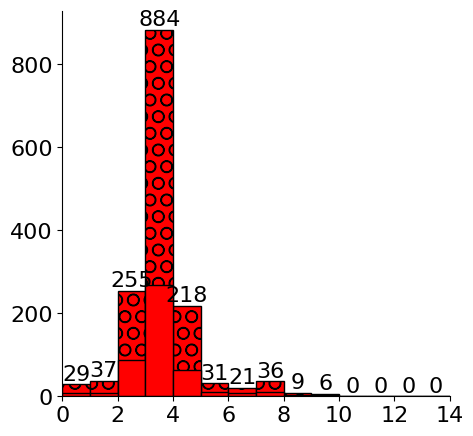

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
counts, edges, bars2 = plt.hist(df_all['Expt_pKa'], color = 'red', edgecolor = 'black', hatch = 'O',
                               bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
counts, edges, bars = plt.hist(df_pkad['Expt_pKa'], color = 'red', edgecolor = 'black', 
                               bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
plt.xlim([0, 14])
plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.bar_label(bars2, fontsize = 16)
plt.show()

In [14]:
df_sub1 = df_sim1[df_sim1['Expt_pKa'] < 2.7].copy()
df_sub2 = df_sim1[(df_sim1['Expt_pKa'] >= 2.7) & (df_sim1['Expt_pKa'] < 3.7)].copy()
df_sub3 = df_sim1[(df_sim1['Expt_pKa'] >= 3.7) & (df_sim1['Expt_pKa'] < 4.7)].copy()
df_sub4 = df_sim1[(df_sim1['Expt_pKa'] >= 4.7) & (df_sim1['Expt_pKa'] < 5.7)].copy()
df_sub5 = df_sim1[(df_sim1['Expt_pKa'] >= 5.7) & (df_sim1['Expt_pKa'] < 7.7)].copy()
df_sub6 = df_sim1[df_sim1['Expt_pKa'] >= 7.7].copy()
df_sim_trn1, df_sim_val1 = trn_val_split(df = df_sub1, rs = 0)
df_sim_trn2, df_sim_val2 = trn_val_split(df = df_sub2, rs = 0)
df_sim_trn3, df_sim_val3 = trn_val_split(df = df_sub3, rs = 0)
df_sim_trn4, df_sim_val4 = trn_val_split(df = df_sub4, rs = 0)
df_sim_trn5, df_sim_val5 = trn_val_split(df = df_sub5, rs = 0)
df_sim_trn6, df_sim_val6 = trn_val_split(df = df_sub6, rs = 0)
df_sim_trn = pd.concat([df_sim_trn1, df_sim_trn2, df_sim_trn3, df_sim_trn4, df_sim_trn5, df_sim_trn6], ignore_index = True)
df_sim_val = pd.concat([df_sim_val1, df_sim_val2, df_sim_val3, df_sim_val4, df_sim_val5, df_sim_val6], ignore_index = True)

In [15]:
print(len(df_sim1), len(df_sim_trn), len(df_sim_val))

1056 952 104


In [16]:
df_sim_trn['dpka_stded'] = ((df_sim_trn['Expt_pKa'] - 3.7) - 0.24) / 2.3 ### get stded_dpka
df_sim_val['dpka_stded'] = ((df_sim_val['Expt_pKa'] - 3.7) - 0.24) / 2.3 ### get stded_dpka
df_sim_trn.to_csv(f'{roinm}_aug_cossim10_all_trn.csv', index = False)
df_sim_val.to_csv(f'{roinm}_aug_cossim10_all_val.csv', index = False)